# 02 — Búsqueda de hiperparámetros: regresión lineal regularizada

La OLS del notebook 01 no regulariza y sufre la colinealidad de las features
mensuales. Acá buscamos la **regularización** óptima sobre una grilla:

- `penalty`: `none` (OLS) · `l2` (Ridge, encoge coeficientes) · `l1` (Lasso, hace
  selección de features) · `elasticnet` (mezcla L1+L2).
- `alpha`: fuerza de la penalización.
- `l1_ratio`: mezcla L1/L2 (solo aplica a elasticnet).

La selección se hace con **validación cruzada temporal** (`evaluacion.buscar`):
folds de ventana expansiva sobre el train, donde la validación es siempre
*posterior* al entrenamiento de cada fold. **El test (≥2021) no se toca en la
búsqueda** — se usa una sola vez, al final, para reportar las métricas del modelo
elegido.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))          # componente_b/ (datos, evaluacion)
warnings.filterwarnings('ignore')                  # silenciar ConvergenceWarning de sklearn

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

import datos, evaluacion as ev
from modelos import LinearRegressor, XGBoostRegressor, NeuralNetRegressor

# Cultivo del estudio (cambiar a 'maiz' para reproducir con maíz).
CULTIVO = 'soja'
ds = datos.prepare(CULTIVO)
print(f'{CULTIVO}: {len(ds.feature_cols)} features | '
      f'train {ds.X_train.shape[0]} filas (≤{datos.TRAIN_END}) | '
      f'test {ds.X_test.shape[0]} filas (≥{datos.TEST_START})')


[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)
soja: 67 features | train 7551 filas (≤2020) | test 942 filas (≥2021)


## La búsqueda

Grid completo, optimizando RMSE de validación.

In [2]:
grid = {
    'penalty':  ['none', 'ridge', 'lasso', 'elasticnet'],
    'alpha':    [0.1, 1.0, 10.0, 50.0, 100.0],
    'l1_ratio': [0.2, 0.5, 0.8],
}
tabla, best = ev.buscar(LinearRegressor, grid, ds, metric='rmse', n_splits=4)
print('Mejores hiperparámetros:', best)
tabla.head(10)

Mejores hiperparámetros: {'penalty': 'elasticnet', 'alpha': 0.1, 'l1_ratio': 0.2}


,penalty,alpha,l1_ratio,cv_rmse,cv_rmse_std
0,elasticnet,0.100,0.200,640.174,107.357
1,lasso,10.000,0.800,640.827,110.896
2,lasso,10.000,0.500,640.827,110.896
3,lasso,10.000,0.200,640.827,110.896
4,elasticnet,1.000,0.800,640.853,103.304
5,elasticnet,0.100,0.500,641.118,109.545
6,lasso,1.000,0.200,642.542,113.527
7,lasso,1.000,0.800,642.542,113.527
8,lasso,1.000,0.500,642.542,113.527
9,ridge,100.000,0.800,642.569,113.640


## Modelo final

Reentrenamos con los mejores hiperparámetros sobre **todo** el train y evaluamos en
el test. Estas son las **métricas del modelo final**.

In [3]:
modelo = LinearRegressor(**best).fit(ds.X_train, ds.y_train)
pred = modelo.predict(ds.X_test)
print('Config final:', modelo.get_config())
# Métricas del modelo final vs el baseline, en la tabla estándar (RMSE/R²/MAE)
ev.tabla([ev.evaluar('Lineal (final)', pred, ds),
          ev.evaluar('baseline media x depto', ev.pred_media_depto(ds), ds)])

Config final: {'model_type': 'linear', 'penalty': 'elasticnet', 'alpha': 0.1, 'l1_ratio': 0.2, 'max_iter': 20000, 'random_state': 42}


,modelo,rmse,r2,mae
0,Lineal (final),662.163,0.253,510.165
1,baseline media x depto,711.185,0.138,586.187


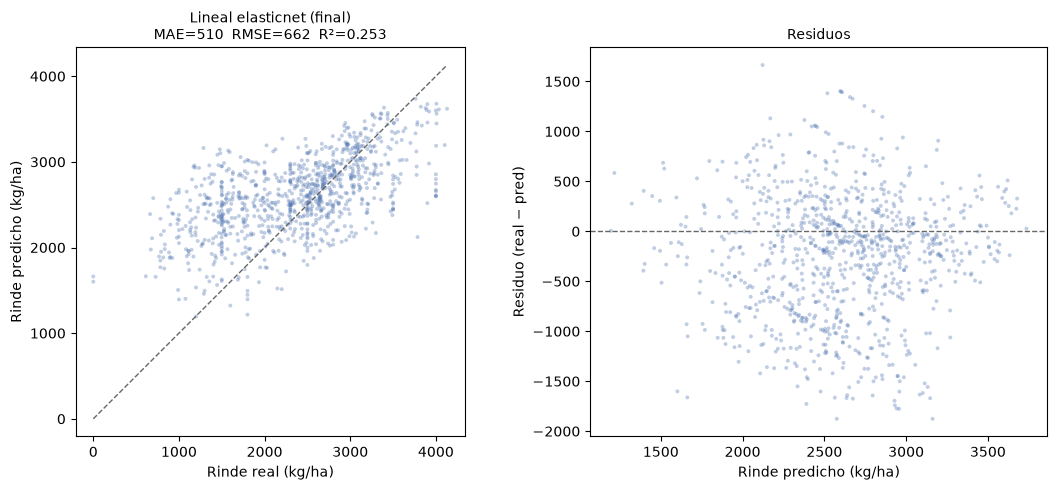

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ev.plot_pred_vs_real(ds.y_test, pred, f'Lineal {best["penalty"]} (final)',
                     color=ev.C_LINEAR, ax=axes[0])
ev.plot_residuos(ds.y_test, pred, 'Residuos', color=ev.C_LINEAR, ax=axes[1])
plt.tight_layout(); plt.show()

## Coeficientes: qué features sobreviven

Con Lasso/ElasticNet muchos coeficientes van a cero — el modelo se queda con las features informativas.

In [5]:
coef = getattr(modelo._model, 'coef_', None)
if coef is not None:
    s = pd.Series(coef, index=ds.feature_cols)
    n_cero = int((s.abs() < 1e-8).sum())
    print(f'coeficientes en cero: {n_cero}/{len(s)}')
    print('\nTop 10 |coef|:')
    print(s.reindex(s.abs().sort_values(ascending=False).index).head(10))

coeficientes en cero: 0/67

Top 10 |coef|:
depto_enc               242.365
year                    163.176
ndvi_avhrr_ene          128.293
ndvi_avhrr_feb          109.820
prectotcorr_dic          69.998
allsky_sfc_sw_dwn_dic    62.322
rh2m_mar                 58.479
rh2m_ene                 58.148
rh2m_dic                -50.432
ws2m_sep                 50.000
dtype: float32


## El mejor modelo del Componente A como features

Con la **configuración final ya elegida**, evaluamos en test el dataset (único,
unificado: clima + NDVI + ERA5) contra tres estrategias que reusan el **mejor
detector del Componente A** (el VAE `recon_prob`, que aprendió a representar el
clima "normal"): concatenar su **espacio latente**, hacer la regresión **solo en
el latente**, y agregar la categórica **`es_anomalo`** (su score umbralado).

El latente/score se computan en `latente.py` (y se cachean). *La primera corrida
entrena el VAE, así que tarda unos minutos.*

In [6]:
tabla_lat = ev.comparar_latente(
    LinearRegressor, best, CULTIVO, fixed=None,
    vae_kwargs=dict(score_seeds=(42, 43, 44)))
tabla_lat

[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)


,variante,n_feats,mae,rmse,r2,mape,smape
0,+ latente,83,451.970,573.847,0.439,25.412,21.575
1,+ es_anomalo,68,488.498,629.474,0.325,27.776,22.988
2,dataset unificado,67,510.165,662.163,0.253,30.121,23.749
3,solo latente,16,599.454,729.554,0.093,28.091,27.179


## Conclusión

La regularización mejora sobre la OLS cruda y da un modelo lineal estable. El techo
del lineal está en su capacidad de capturar solo relaciones **lineales** entre clima
y rinde; los notebooks 03 (XGBoost) y 04 (red neuronal) prueban si lo no-lineal
paga. En cuanto a features: las de ERA5/NDVI y el latente del VAE se evalúan arriba
(ver la conclusión transversal del nb 05).